In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("lc_accepted_clean.csv", low_memory=False)

print("Rows:", df.shape[0])
print("Default rate:", df["default"].mean())

Rows: 1345350
Default rate: 0.19964990522912254


## Is the loan interest rate consistent with the default rate?
I check if the higher rates are positively correlated with risk

In [5]:
df.groupby(pd.qcut(df["int_rate"], 10))["default"].mean()

int_rate
(5.308999999999999, 7.39]    0.049142
(7.39, 8.9]                  0.084985
(8.9, 10.49]                 0.121438
(10.49, 11.53]               0.154836
(11.53, 12.74]               0.172270
(12.74, 13.98]               0.201881
(13.98, 15.22]               0.233533
(15.22, 16.99]               0.268122
(16.99, 19.52]               0.318601
(19.52, 30.99]               0.401653
Name: default, dtype: float64

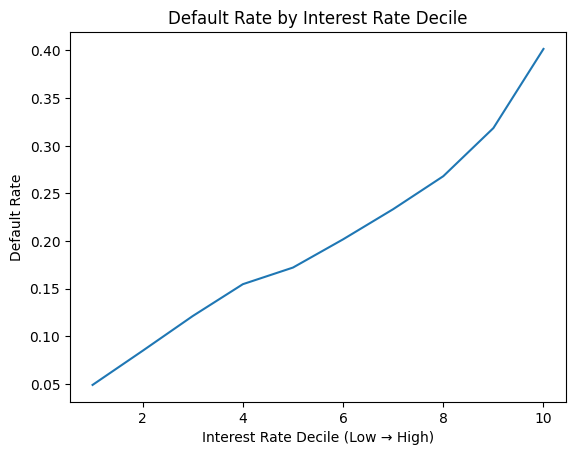

In [11]:
df["int_rate_bin"] = pd.qcut(df["int_rate"], 10)

int_default = df.groupby("int_rate_bin")["default"].mean()

plt.figure()
plt.plot(range(1, 11), int_default.values)
plt.xlabel("Interest Rate Decile (Low → High)")
plt.ylabel("Default Rate")
plt.title("Default Rate by Interest Rate Decile")
plt.savefig("../public/default_rate_by_int_rate_decile.png", dpi=300, bbox_inches="tight")
plt.show()

## Is the debt-to-income ratio consistent with the default rate?
I check the form of the relationship between leverage and risk

In [10]:
df.groupby(pd.qcut(df["dti"], 10))["default"].mean()

dti
(-1.001, 7.27]    0.146563
(7.27, 10.49]     0.152612
(10.49, 13.02]    0.162314
(13.02, 15.32]    0.173105
(15.32, 17.61]    0.184801
(17.61, 19.98]    0.197089
(19.98, 22.6]     0.210828
(22.6, 25.69]     0.228358
(25.69, 29.78]    0.250919
(29.78, 999.0]    0.290174
Name: default, dtype: float64

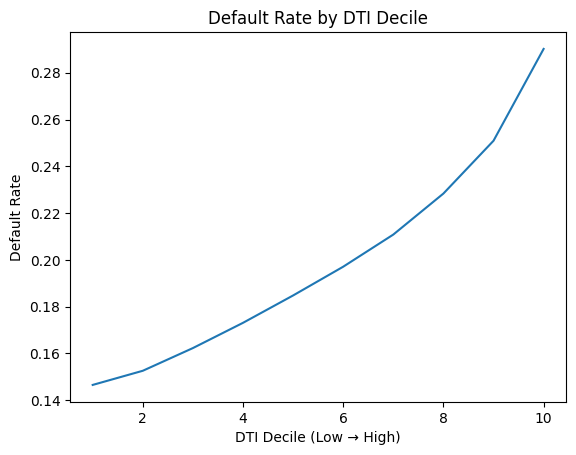

In [12]:
df["dti_bin"] = pd.qcut(df["dti"], 10)

dti_default = df.groupby("dti_bin")["default"].mean()

plt.figure()
plt.plot(range(1, 11), dti_default.values)
plt.xlabel("DTI Decile (Low → High)")
plt.ylabel("Default Rate")
plt.title("Default Rate by DTI Decile")
plt.savefig("../public/default_rate_by_dti_decile.png", dpi=300, bbox_inches="tight")
plt.show()

## Are there dynamic effects on default?
I check if there are some differences between the default rate and each year, in order to check if there are some effects of years of crisis and if there is some change in the underwriting quality

In [7]:
df["issue_d"] = pd.to_datetime(df["issue_d"])

df["issue_year"] = df["issue_d"].dt.year

df.groupby("issue_year")["default"].mean()

issue_year
2007    0.179283
2008    0.158131
2009    0.125954
2010    0.128901
2011    0.151789
2012    0.161973
2013    0.155960
2014    0.184498
2015    0.201850
2016    0.232859
2017    0.231330
2018    0.157570
Name: default, dtype: float64

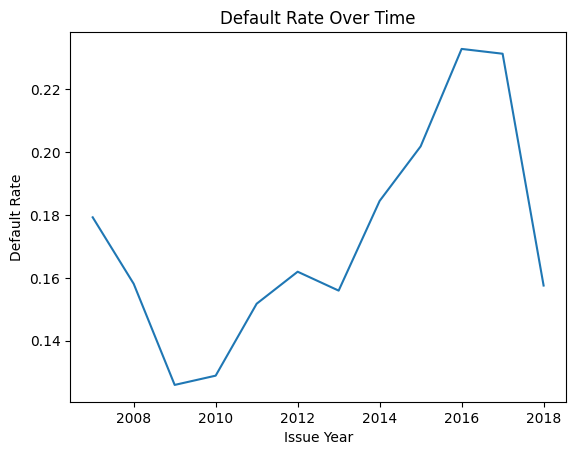

In [13]:
df["issue_d"] = pd.to_datetime(df["issue_d"])
df["issue_year"] = df["issue_d"].dt.year

year_default = df.groupby("issue_year")["default"].mean()

plt.figure()
plt.plot(year_default.index, year_default.values)
plt.xlabel("Issue Year")
plt.ylabel("Default Rate")
plt.title("Default Rate Over Time")
plt.savefig("../public/default_rate_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

## Outliers
I check for outliers in the distributions of annual income and revolving utilization

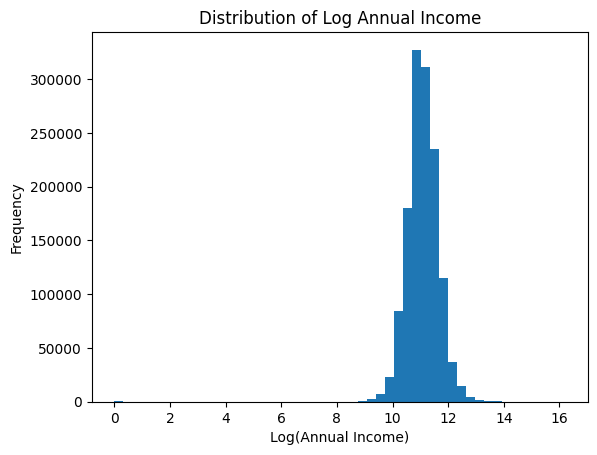

In [13]:
plt.figure()
plt.hist(np.log1p(df["annual_inc"]), bins=50)
plt.xlabel("Log(Annual Income)")
plt.ylabel("Frequency")
plt.title("Distribution of Log Annual Income")
plt.show()

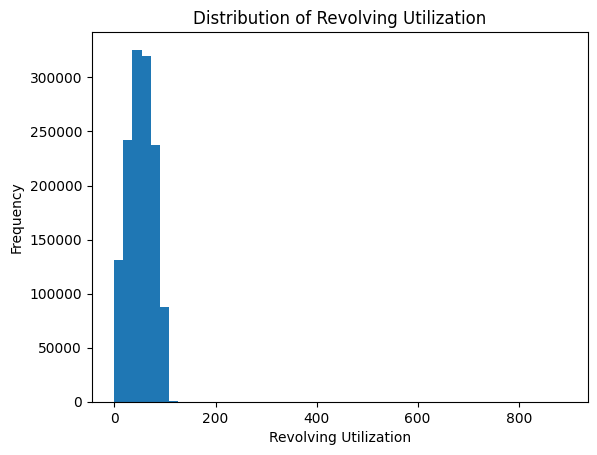

In [14]:
plt.figure()
plt.hist(df["revol_util"].dropna(), bins=50)
plt.xlabel("Revolving Utilization")
plt.ylabel("Frequency")
plt.title("Distribution of Revolving Utilization")
plt.show()

## Exploratory Data Analysis Summary

---

### 1. Risk and Pricing Consistency (Interest Rate)

Default rates increase monotonically across interest rate deciles.

This suggests:

- Risk-based pricing is functioning as expected.
- Higher interest rates are associated with higher realized default probabilities.
- There is no visible misalignment between risk and pricing structure.

This also raises a modeling consideration: whether interest rate should be included as a predictor (since it partially reflects internal underwriting decisions).

---

### 2. Debt Burden (DTI) and Risk

Default rates increase across DTI deciles, with evidence of nonlinear (posibely quadratic) behavior at higher DTI levels.

This confirms:

- Debt burden is an economically meaningful predictor of default.
- Risk may accelerate at high DTI levels.
- Nonlinear modeling approaches (e.g., tree-based models) may capture this effect more effectively than linear models without transformations.

---

### 3. Temporal Drift in Default Rates

Default rates vary meaningfully over time:

- 2008–2010: declining default rates  
- 2010–2016: rising default rates  
- 2016–2018: declining default rates  

This suggests:

- Macroeconomic cycle effects
- Changes in underwriting standards
- Shifts in portfolio composition over time

This finding has a critical modeling implication: A time-based train/test split is necessary to avoid forward-looking bias and to properly evaluate out-of-sample performance.

Random cross-validation would likely overstate model performance.

---

### 4. Key Modeling Implications

From this EDA, several conclusions guide the modeling strategy:

1. The dataset is economically coherent and consistent.
2. Core risk drivers (interest rate, DTI) exhibit expected monotonic relationships.
3. Temporal instability requires time-aware validation.
4. Nonlinear effects suggest value in comparing logistic regression and gradient boosting.
5. Feature engineering should preserve interpretability while allowing for nonlinearity where appropriate.
6. There is no evidence of outliers.

---